In [5]:
import pickle 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
with open("../data/titanic_preprocessing.pkl", "rb") as f:
    df = pickle.load(f)

with open("../data/titanic_preprocessing.pkl", "rb") as f:
    df = pickle.load(f)


df.drop(['Sex', "Embarked", "honorific"], axis=1, inplace=True)

target = df.pop("Survived")
X_train , X_test, y_train, y_test = train_test_split(df, target, test_size=0.2, stratify=target, random_state=42)


In [6]:
pd.options.display.float_format = '{:.3f}'.format

In [7]:
X_train_case_1 = X_train.copy()

In [8]:
X_train_case_1.head(2)

,Pclass,Age_x,SibSp,Parch,Fare,Embarked_Q,Embarked_S,honorific_Mr,honorific_Mrs,honorific_Others,Sex_male
620,1,42,1,0,52.554,0.000,1.000,1.000,0.000,0.000,1.000
480,2,32,0,0,0.000,0.000,1.000,1.000,0.000,0.000,1.000


In [9]:
ss = StandardScaler()
ss.fit(X_train_case_1)
X_train_case_1_scaler = ss.transform(X_train_case_1)


In [10]:
pd.DataFrame(X_train_case_1_scaler).describe()

,0,1,2,3,4,5,6,7,8,9,10
count,711.000,711.000,711.000,711.000,711.000,711.000,711.000,711.000,711.000,711.000,711.000
mean,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000
std,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001,1.001
min,-1.601,-2.224,-0.468,-0.461,-0.646,-0.301,-1.662,-1.167,-0.390,-0.290,-1.345
25%,-0.391,-0.647,-0.468,-0.461,-0.486,-0.301,-1.662,-1.167,-0.390,-0.290,-1.345
50%,0.819,0.029,-0.468,-0.461,-0.354,-0.301,0.602,0.857,-0.390,-0.290,0.743
75%,0.819,0.404,0.470,-0.461,-0.028,-0.301,0.602,0.857,-0.390,-0.290,0.743
max,0.819,3.783,7.037,6.750,9.744,3.324,0.602,0.857,2.562,3.454,0.743


In [11]:
X_test_case_1_scaler = ss.transform(X_test)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

lg = LogisticRegression()
lg.fit(X_train_case_1_scaler , y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [13]:
accuracy_score(lg.predict(X_test_case_1_scaler), y_test)

0.8202247191011236

In [15]:
image_url = "https://edge.pilldoc.co.kr/Products/A5_Sample_Coral_Full.png"

from urllib.request import urlretrieve

urlretrieve(image_url, "../data/약봉투.png")


('../data/약봉투.png', <http.client.HTTPMessage at 0xfffeb92d3ef0>)

In [17]:
from typing import TypedDict
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langgraph.graph import StateGraph, START, END

from typing import Literal
from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from dotenv import load_dotenv
import os


load_dotenv()

api_key = os.getenv("OLLAMA_API_KEY")
headers = {
   "Authorization": f"Bearer {api_key}"
}

llm = ChatOllama(
   base_url="https://ollama.com", # 원격 서버 주소
   model="gemma4:31b-cloud",
   client_kwargs={"headers": headers},
   temperature=0.2,
   reasoning=True
)
llm.invoke("hi")


AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user said "hi".\nThe user is initiating a conversation.\n\n    *   Acknowledge the greeting.\n    *   Offer assistance.\n    *   Keep it friendly and open-ended.\n"Hello! How can I help you today?" or "Hi there! What\'s on your mind?"'}, response_metadata={'model': 'gemma4:31b-cloud', 'created_at': '2026-08-05T01:58:01.328362024Z', 'done': True, 'done_reason': 'stop', 'total_duration': 661897770, 'load_duration': None, 'prompt_eval_count': 17, 'prompt_eval_duration': None, 'eval_count': 80, 'eval_duration': None, 'logprobs': None, 'model_name': 'gemma4:31b-cloud', 'model_provider': 'ollama'}, id='lc_run--019fcfa4-519a-71c0-9dcb-4cd90086403b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 80, 'total_tokens': 97})

In [19]:
import base64
with open("../data/약봉투.png", "rb") as f:
    img_data = base64.b64encode(f.read()).decode('utf-8')


In [ ]:
openai_llm = ""

In [ ]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """주어진 이미지에서 약품명/성분 값만 추출 할 것"""),
        ("human", [
                    {
                        "type" : "image_url", 
                        "image_url" : {"url" : "data:{mime_type};base64, {img_data}"}
                    }
                ])

    ]
)

In [26]:
chain = prompt | openai_llm

In [27]:
drug_list = chain.invoke({
    'mime_type' : "image/jpeg",
    "img_data" : img_data
})


In [28]:
print(drug_list.content)

알마겔정 / 알마게이트 500mg  
슈가메트서방정5/1000 / 에보글립틴타르타르산염 6.869mg, 메트포르민염산염 1000mg  
듀비메트서방정0.5/1000 / 로베글리타존황산염 0.5mg, 메트포르민염산염 1000mg  
경동아스피린장용정 / 아스피린 100mg  
리피토정10mg / 아토르바스타틴칼슘수화물 10.8mg  
애니코프캡슐300mg / 테오필린 300mg  
다이크로짇정 / 히드로클로로티아지드 25mg  
소론도정 / 프레드니솔론 5mg


In [29]:
import requests
from bs4 import BeautifulSoup

In [30]:
url = "https://health.kr/searchDrug/result_drug.asp?drug_cd=2016070100016"

In [33]:
BeautifulSoup(requests.get(url).text).find('article', id="druginfo02")

<article id="druginfo02">
<h3 class="subtitle">허가정보 ∙ 복약정보</h3>
<ul class="tab2 mb0" id="subtab">
<li class="selected" onclick="$(window).scrollTop($('#effect').offset().top-200);"><a href="javascript:void(0)">전 체</a></li>
<li onclick="$(window).scrollTop($('#effect').offset().top-200);"><a href="javascript:void(0)">효능 · 효과</a></li>
<li onclick="$(window).scrollTop($('#dosage').offset().top-200);"><a href="javascript:void(0)">용법 · 용량</a></li>
<li onclick="$(window).scrollTop($('#caution').offset().top-200);"><a href="javascript:void(0)">주의사항</a></li>
<li onclick="$(window).scrollTop($('#drug_take').offset().top-200);"><a href="javascript:void(0)">복약정보</a></li>
<li onclick="$(window).scrollTop($('#all_upso_tab').offset().top-200);"><a href="javascript:void(0)">제조/수입사</a></li>
</ul>
<div class="tab2_cont">
<div class="druginfo" id="efficacy_effect">
<h4 class="title_dept3 ico">효능 · 효과</h4>
<a href="javascript://" onclick="copyPlainTextFromElementById('effect');" style="border: 1px solid 

In [36]:
search_url = "https://health.kr/searchDrug/search_total_result.asp"

In [34]:
payload = {"search_word":"%EB%93%80%EB%B9%84%EB%A9%94%ED%8A%B8%EC%84%9C%EB%B0%A9%EC%A0%950.5%2F1000mg",
"search_flag":"all"}


In [37]:
search_result = requests.post(search_url, data=payload)

search_result.text.find("csrf")


1418

In [38]:
import re 
p = re.compile("csrfToken = \"([A-Z0-9]+)\"")


In [39]:
p.findall(search_result.text)

['31123391546CBE18010D1BD00']

In [40]:
with requests.Session() as s:
    search_result = s.post(search_url, data=payload)
    print(p.findall(search_result.text)[0])


3112342591C8761805D9F3D00


In [43]:
detail_search_url = "https://health.kr/searchDrug/ajax/ajax_commonSearch.asp?"

In [44]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "X-Requested-With": "XMLHttpRequest",
    "Origin": "https://health.kr",
    "Referer": "https://health.kr/searchDrug/search_total_result.asp",
}


In [41]:
search_payload = {"search_word":"게보린",
                    "search_flag":"all",}

search_payload

{'search_word': '게보린', 'search_flag': 'all'}

In [45]:
with requests.Session() as s:
    search_result = s.post(search_url, data=payload)
    print(search_result.status_code)
    token = p.findall(search_result.text)[0]
    print(token)
    headers['x-csrf-token'] = token
    search_payload['csrf_token'] = token
    # r = s.post(detail_search_url.format(token), data=search_payload, headers=headers)
    headers['X-CSRF-Token'] = token
    r = s.post(
        detail_search_url,
        params={"search_word": "게보린", "csrf_token": token, "search_flag": "all"},
        data={"csrf_token": token},
        headers=headers,
    )
    print(r.status_code)
    


200
31127173846AB61806F333D00
200


In [46]:
r = requests.get("https://health.kr/searchDrug/result_drug.asp?drug_cd=" +r.json()[0]['drug_code'])

In [47]:
from bs4 import BeautifulSoup

In [48]:
bs = BeautifulSoup(r.text)

In [ ]:
print(bs.find("section", id="search_detail_result").text)


의약품 상세정보
의약품검색의약품 상세정보
의약품 상세정보
복약안내문
동일성분 의약품
상호작용
자료출처 : 식품의약품안전처
제품 기본정보
허가정보 바로가기
출 력
정보 수정요청
구매가능 약국 찾기제품명
 복사장축(mm)단축(mm)두께(mm)성상식별정보
제품정보
제품설명서장축(mm)단축(mm)두께(mm)성상의약품이미지 확대보기
식별정보
제품정보
제품설명서성분 / 함량
 복사동일성분 의약품첨가제 복사
첨가제 더보기
도핑금지약물정보
 복사
	
			경기기간중 : 허용 경기기간외 : 허용
상세정보 확인
※ 국소투여경로 등 예외 적용이 있을 수 있으니, KADA 누리집으로 연결되는 "상세정보 확인"을 클릭하여 주시기 바랍니다.
전문 / 일반 복사단일 / 복합
 복사제조 / 수입사회사명회사 영문명주소전화번호FAX홈페이지제형
 복사투여경로
 복사성상
 복사허가일
 복사
[신약]
재심사
 복사대조 / 생동
 복사급여정보 복사
약가이력정보약가이력정보
ATC 코드
 복사
KPIC 약효분류
 복사
Acetaminophen : 
							
						
						
							통증 질환 >  
							비마약성 진통제 >  
							중추성 진통제
							 > p-aminophenol 유도체Isopropylantipyrine : 
							
						
						
							근골격계/결합조직질환 >  
							비스테로이드성 소염진통제(NSAIDs) >  
							Pyrazolone 유도체 (Pyrine계)
KPIC 학술 팜리뷰
아세트아미노펜 바로알기, 약학정보원(곽혜선), 2013-09-24
				
대한약사저널 OTC vs OTC
여성 진통제 '어떻게 고르는 것이 좋을까', 약국약학연구회 현고은 약사, 2021-04-19
				 비밀노트
NSAIDs 알고씁시다!, 박정빈 약사, 2021-03-08
				
제품설명서
보 기 ( 2017-10-10 게시 )
의약품안전성정보(DUR)상세보기
포장단위(식약처 기준)심평원 기준 포장단위심평원 기준 포장

In [57]:
llm = ChatOllama(
   base_url="https://ollama.com", # 원격 서버 주소
   model="gemma4:31b-cloud",
   client_kwargs={"headers": headers},
   temperature=0.2,
   reasoning=True
)

In [58]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", """ 당신은 유능한 약사입니다. 제시된 의약품 내용을 
                         초등학생도 이해하기 쉽게 약효 및 주의사항을 쉽게 설명하세요"""),
        ("human", "{question}")
    ]
)


In [59]:
drug_chain = prompt | llm | StrOutputParser()


In [60]:
drug_result = drug_chain.invoke({'question' : bs.find("section", id="search_detail_result").text})


In [62]:
print(drug_result)

안녕하세요! 여러분의 건강을 지켜주는 친절한 약사 선생님이에요. 💊

오늘 설명해 줄 약은 **'게보린'**이라는 약이에요. 이 약이 어떤 약인지, 어떻게 써야 하는지 초등학생 친구들도 이해하기 쉽게 아주 쉽게 설명해 줄게요!

---

### 1. 🌟 이 약은 어떤 약인가요?
한마디로 말하면 **'통증을 없애주고 열을 내려주는 약'**이에요. 
우리 몸 여기저기가 아플 때 도움을 주는 고마운 약이죠.

*   **이럴 때 먹어요:** 머리가 띵하게 아픈 두통, 치과 치료 후 치통, 목이 아픈 인후통, 근육통, 혹은 갑자기 열이 나고 으슬으슬 추울 때 먹으면 도움이 돼요.

### 2. 💊 어떻게 먹어야 하나요? (어른들 기준)
이 약은 **어른들이 먹는 약**이에요.
*   **양:** 한 번에 1알씩, 하루에 최대 3번까지만 먹어요.
*   **시간:** 다음 약을 먹을 때까지 최소 **4시간**은 기다려야 해요.
*   **주의:** 빈속(배가 고픈 상태)에 먹으면 위가 아플 수 있으니, **꼭 식사 후에** 먹는 것이 좋아요.

### 3. ⚠️ [매우 중요!] 꼭 기억하세요! (주의사항)

**❌ 어린이는 절대 안 돼요!**
가장 중요한 점이에요. **15세 미만의 어린이(초등학생 친구들 포함)는 이 약을 절대 먹으면 안 됩니다.** 어린이들에게는 맞지 않는 성분이 들어있어 위험할 수 있어요. 어린이가 아플 때는 반드시 어린이 전용 약을 처방받아 먹어야 해요.

**❌ 술과 함께 먹으면 위험해요!**
술을 많이 마신 사람이 이 약을 먹으면, 우리 몸에서 독소를 걸러주는 **'간'**이라는 장기가 크게 다칠 수 있어요.

**❌ 다른 약과 섞어 먹을 때 조심하세요!**
이 약에는 '아세트아미노펜'이라는 성분이 들어있어요. 그런데 다른 감기약이나 진통제에도 이 성분이 들어있는 경우가 많아요. 너무 많이 먹게 되면 간이 아플 수 있으니, 다른 약을 이미 먹고 있다면 꼭 약사 선생님께 물어봐야 해요.

### 4. 🚨 이럴 땐 바로 멈추고 의사 선생님께 가세

In [63]:
import requests 
import re 
from langchain_core.tools import tool


In [110]:
@tool
def search_list(query : str) -> list :
    """   
    이 함수는 요청한 의약품 이름으로 검색하여 검색된 약품 목록을 반환하는 함수 
    input : 약품명  예) 아로나민골드 
    return : 아로나민골드가 포함된 리스트 형태 
    """
    p = re.compile("csrfToken = \"([A-Z0-9]+)\"")
    search_url = "https://health.kr/searchDrug/search_total_result.asp"
    payload = {"search_word": "",
             "search_flag":"all"}

    detail_search_url = "https://health.kr/searchDrug/ajax/ajax_commonSearch.asp?"
    headers = {
                    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
                    "X-Requested-With": "XMLHttpRequest",
                    "Origin": "https://health.kr",
                    "Referer": "https://health.kr/searchDrug/search_total_result.asp",
                }

    with requests.Session() as s:
        search_result = s.post(search_url, data=payload)
        token = p.findall(search_result.text)[0]
        r = s.post(
            detail_search_url,
            params={"search_word": query, "csrf_token": token, "search_flag": "all"},
            data={"csrf_token": token},
            headers=headers,
        )
    return r.json()



In [111]:
from bs4 import BeautifulSoup, SoupStrainer
from langchain_community.document_loaders import WebBaseLoader

@tool
def drug_detail(code: str) -> str:
    """  
    전달 받은 의약품 코드를 사용하여 상세 정보를 가져오는 함수 
    input : drug_cd : 예) A11A0340A0195
    return : 의약품 상세 정보 
    """
    r = requests.get(f"https://health.kr/searchDrug/result_drug.asp?drug_cd={code}")
    data = WebBaseLoader([f"https://health.kr/searchDrug/result_drug.asp?drug_cd={code}"],
    bs_kwargs={'parse_only' : SoupStrainer("section", id="search_detail_result")})
    return data.load()



In [134]:
from typing import TypedDict, Annotated, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage


In [113]:
class DrugState(TypedDict):
    query: str  # 사용자 질문 
    drug_list : list[dict] # 검색할 의약품 목록 
    drug_detail : str  # 의약품 상세 정보 
    messages : Annotated[list[BaseMessage], add_messages]
    report : str  # 약품 정보 요약 


In [114]:
tools =[search_list, drug_detail]
llm_tools = llm.bind_tools(tools)


In [122]:
def use_tools_node(state:DrugState) -> dict:
    response = llm_tools.invoke(state['messages'])
    return {'messages' : [response]}



In [128]:
def generate_report_node(state: DrugState) -> dict:
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", """ 당신은 유능한 약사입니다. 제시된 의약품 내용을 
                           이해하기 쉽게 약효 및 주의사항을 쉽게 설명하세요"""),
            ("human", "질문 : {question}")
        ]
    )
    drug_chain = prompt | llm | StrOutputParser()
    
    query = " ".join([str(m) for m in state['messages']])
    result = drug_chain.invoke({'question' : query})
    return {'report' : result}



In [129]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.graph import StateGraph, START, END


In [130]:
tool_node = ToolNode( tools)

builder = StateGraph(DrugState)
builder.add_node("use_tools", use_tools_node)
builder.add_node("generate_report", generate_report_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "use_tools")
builder.add_conditional_edges(
    "use_tools",
    tools_condition,
    {
        "tools" : "tools",
        "__end__" : "generate_report"
    }
)
builder.add_edge("tools", "use_tools")
builder.add_edge("generate_report", END)
agent = builder.compile()



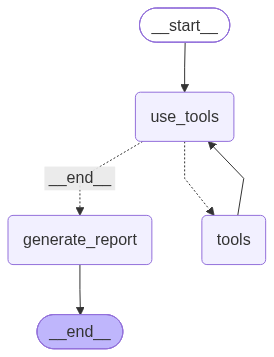

In [125]:
agent

In [131]:
%colors lightbg

In [135]:
report_rt = agent.invoke({'messages' : 
                         [
                            SystemMessage(content="너의 판단보다 도구를 우선시 할 것"),
                            HumanMessage(content="아로나민골드")
                          ]
})


In [136]:
report_rt

{'messages': [SystemMessage(content='너의 판단보다 도구를 우선시 할 것', additional_kwargs={}, response_metadata={}, id='106d9c40-70ae-4e22-a1b5-b14280a0c84f'),
  HumanMessage(content='아로나민골드', additional_kwargs={}, response_metadata={}, id='d4dff3ef-7c81-4092-9d76-c90165bf0297'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user provided the keyword "아로나민골드" (Aronamin Gold).\nThis is a request for information about a specific medication.\nI should first search for the medication to get its code and then retrieve the detailed information.\n\n1. **Search for the drug**: Use `search_list` with the query "아로나민골드".\n2. **Get detailed info**: Once I have the list of drugs, I\'ll identify the correct one and use `drug_detail` with its code.'}, response_metadata={'model': 'gemma4:31b-cloud', 'created_at': '2026-08-05T07:20:05.33494039Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1350858003, 'load_duration': None, 'prompt_eval_count': 201, 'prompt_eval_duration': None, '